<a href="https://colab.research.google.com/github/SachinKumar-IT/AI-ML-Learning/blob/main/decisionTree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split

In [2]:
#Titanic Dataset
titanic= sns.load_dataset("titanic")

In [4]:
titanic.head()
titanic.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,177
sibsp,0
parch,0
fare,0
embarked,2
class,0
who,0


In [5]:
features=["pclass", "sex","fare", "embarked", "age"]
target=["survived"]

In [6]:
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [8]:
# Missing Data

from sklearn.impute import SimpleImputer

imp_median= SimpleImputer(strategy="median")
titanic[["age"]]= imp_median.fit_transform(titanic[["age"]])

imp_freq=SimpleImputer(strategy="most_frequent")
titanic[["embarked"]] = imp_freq.fit_transform(titanic[["embarked"]])

In [9]:
titanic.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,0
sibsp,0
parch,0
fare,0
embarked,0
class,0
who,0


In [12]:
#Encoding

from sklearn.preprocessing import LabelEncoder

le=LabelEncoder()

titanic["sex"]=le.fit_transform(titanic["sex"])
titanic["embarked"]=le.fit_transform(titanic["embarked"])

In [13]:
X=titanic[features]
y=titanic[target]

In [16]:
X_train,X_test,y_train,y_test=train_test_split(
    X,y, test_size=0.2, random_state=42
)

In [17]:
# Decision Tree

from sklearn.tree import DecisionTreeClassifier

model=DecisionTreeClassifier()
model.fit(X_train, y_train)

DecisionTreeClassifier()

In [18]:
from sklearn.metrics import accuracy_score

y_pred=model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.7597765363128491


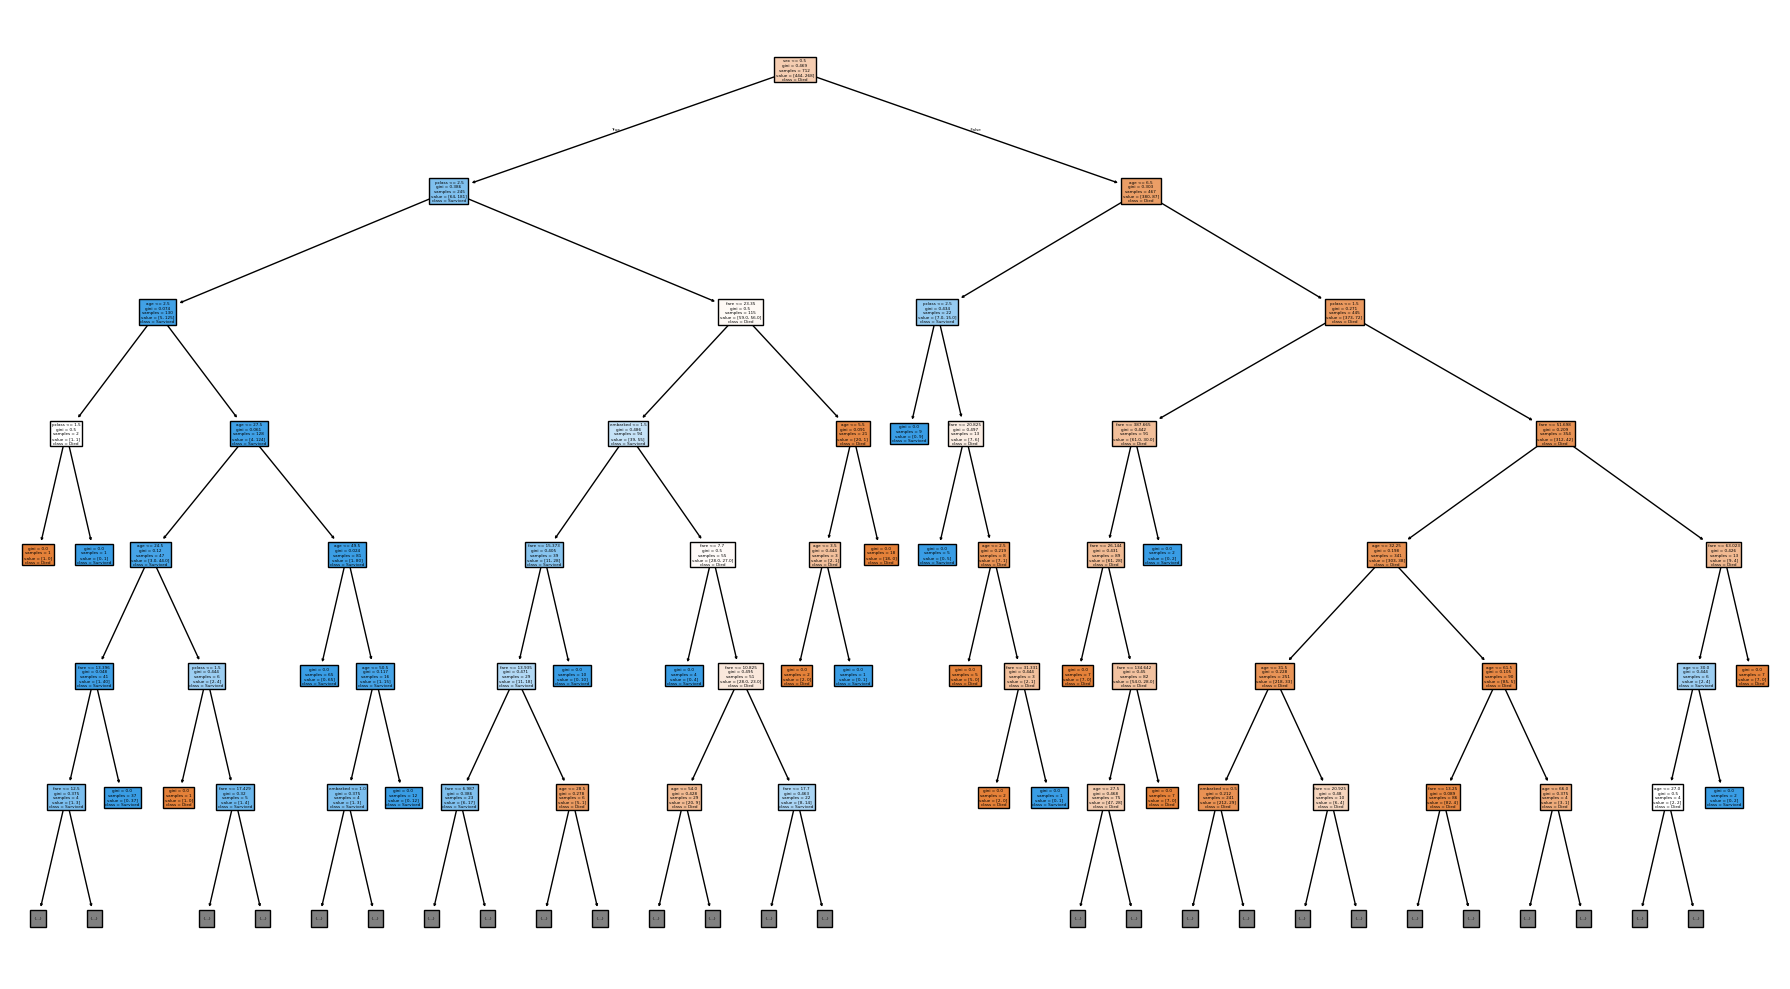

In [20]:
# Plotting Tree
from sklearn.tree import plot_tree

plt.figure(figsize=(18,10))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=["Died", "Survived"],
    filled=True,
    max_depth=6   #Plotting Size(Zooming Tree)
)

plt.tight_layout()
plt.show()